<a href="https://colab.research.google.com/github/pepealania/image-processing-project-tutorial-deep-learning-happy-not-happy-classification/blob/main/pipeline/Image_Processing_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAVDESS SETUP

##**1. Delete GDrive Ravdess**

In [ ]:
import shutil
import os
#get the file path to delete
ravdess_dir = "/content/RAVDESS"

if os.path.exists(ravdess_dir):
#if file path exists delete RAVDESS folder
    try:
        shutil.rmtree(ravdess_dir)
        print(f"Directory '{ravdess_dir}' and its contents deleted successfully.")
    except OSError as e:
        print(f"Error: Could not delete directory '{ravdess_dir}' - {e}")
else:
#if the folder does not exist
    print(f"Directory '{ravdess_dir}' does not exist.")

Directory '/content/RAVDESS' does not exist.


##**2. Load Data from GDrive Ravdess**

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Unzip all RAVDESS video files into Colab
import os

zip_dir = "/content/drive/MyDrive/RAVDESS"
output_dir = "/content/RAVDESS"

os.makedirs(output_dir, exist_ok=True)

for zip_file in os.listdir(zip_dir):
    if zip_file.endswith(".zip"):
        zip_path = os.path.join(zip_dir, zip_file)
        !unzip -o -q "{zip_path}" -d "{output_dir}"

print("✅ All RAVDESS video files extracted!")

# 3. Extract frames from videos (using OpenCV)
import cv2

frame_dir = "/content/RAVDESS_frames"
os.makedirs(frame_dir, exist_ok=True)

for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.endswith(".mp4"):
            video_path = os.path.join(root, file)
            cap = cv2.VideoCapture(video_path)
            count = 0
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                # Save 1 frame per second
                if int(cap.get(cv2.CAP_PROP_POS_FRAMES)) % int(cap.get(cv2.CAP_PROP_FPS)) == 0:
                    frame_name = f"{os.path.splitext(file)[0]}_{count}.jpg"
                    cv2.imwrite(os.path.join(frame_dir, frame_name), frame)
                    count += 1
            cap.release()

print("✅ Frames extracted from RAVDESS videos!")

# Count all videos
video_count = 0

for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.endswith(".mp4"):
            video_count += 1

print(f"Total videos: {video_count}")


Mounted at /content/drive
✅ All RAVDESS video files extracted!
✅ Frames extracted from RAVDESS videos!
Total videos: 2760


# DATASET PREPARATION

##**3. How many frames have been loaded?**

In [ ]:
import os

total_frames = len(os.listdir(frame_dir))
print(f"Total frames extracted: {total_frames}")

Total frames extracted: 9003


##**4. Load Frames into the Dataset**

In [ ]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# frame_dir is already defined from previous cells see step 2 "Load Data from GDrive Ravdess"

# Define the dataset class (as used in previous cells)
class RAVDESSFrames(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
        ]
        # Binary labels: happy (03 emotion code) vs. not happy
        self.labels = [
            1 if "-03-" in f else 0  # Emotion code '03' for happy
            for f in self.image_files
        ]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Define the transformation to apply to the frames
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Initialize the dataset
frames_dataset = RAVDESSFrames(frame_dir, transform=transform)

print(f"Total frames loaded into dataset: {len(frames_dataset)}")
print(f"First frame label: {frames_dataset[0][1]}")


Total frames loaded into dataset: 9003
First frame label: 0


##**5. Count happy and unhappy data in the Dataset**

In [ ]:
from collections import Counter

# Assuming frames_dataset is already defined from previous cells

# Extract all labels
all_labels = [label for _, label in frames_dataset]

# Count occurrences of each label
label_counts = Counter(all_labels)

# Get total number of frames
total_frames = len(all_labels)

# Get counts for happy (label 1) and not happy (label 0)
happy_count = label_counts.get(1, 0)
not_happy_count = label_counts.get(0, 0)

# Calculate percentages
happy_percentage = (happy_count / total_frames) * 100 if total_frames > 0 else 0
not_happy_percentage = (not_happy_count / total_frames) * 100 if total_frames > 0 else 0

print(f"Total frames: {total_frames}")
print(f"Happy frames (label 1): {happy_count} ({happy_percentage:.2f}%)")
print(f"Not Happy frames (label 0): {not_happy_count} ({not_happy_percentage:.2f}%)")


Total frames: 9003
Happy frames (label 1): 1166 (12.95%)
Not Happy frames (label 0): 7837 (87.05%)


# DATASET SPLIT

##**6. Split Dataset to training+validation = 80% and test = 20%**

In [ ]:
import os
import random
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split, KFold

# ============================================================
# 1. Dataset Class
# ============================================================

class RAVDESSFrames(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================================
# 2. Transforms
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 3. Collect All Data
# ============================================================

# Example:
# frame_dir = "/content/RAVDESS_frames"

all_image_files = [
    os.path.join(frame_dir, f)
    for f in os.listdir(frame_dir)
]

happy_data = []
not_happy_data = []

for img_path in all_image_files:

    filename = os.path.basename(img_path)

    # Emotion code '03' = happy
    label = 1 if "-03-" in filename else 0

    if label == 1:
        happy_data.append((img_path, label))
    else:
        not_happy_data.append((img_path, label))

print(f"Original happy samples: {len(happy_data)}")
print(f"Original not happy samples: {len(not_happy_data)}")


# ============================================================
# 4. Balance Dataset (50/50)
# ============================================================

min_class_size = len(happy_data)

random.shuffle(not_happy_data)

balanced_not_happy_data = not_happy_data[:min_class_size]

balanced_data = happy_data + balanced_not_happy_data

random.shuffle(balanced_data)

print(f"\nBalanced dataset size: {len(balanced_data)}")

balanced_happy_count = sum(
    1 for _, label in balanced_data if label == 1
)

balanced_not_happy_count = sum(
    1 for _, label in balanced_data if label == 0
)

print(f"Happy samples: {balanced_happy_count}")
print(f"Not happy samples: {balanced_not_happy_count}")


# ============================================================
# 5. Split Into:
#    - 80% train/validation (for KFold)
#    - 20% generalization test set
# ============================================================

labels = [label for _, label in balanced_data]

train_val_data, test_data = train_test_split(
    balanced_data,
    test_size=0.20,
    stratify=labels,
    random_state=42,
    shuffle=True
)

print("\n==============================")
print(f"Train/Validation pool: {len(train_val_data)}")
print(f"Generalization test set: {len(test_data)}")


# ============================================================
# 6. K-Fold Setup on the 80%
# ============================================================

NUM_FOLDS = 5

kf = KFold(
    n_splits=NUM_FOLDS,
    shuffle=True,
    random_state=42
)

BATCH_SIZE = 32

fold_loaders = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_data)):

    print(f"\n========== Fold {fold+1} ==========")

    train_fold = [train_val_data[i] for i in train_idx]
    val_fold = [train_val_data[i] for i in val_idx]

    print(f"Train fold size: {len(train_fold)}")
    print(f"Validation fold size: {len(val_fold)}")

    # Create datasets
    train_dataset = RAVDESSFrames(
        train_fold,
        transform=train_transform
    )

    val_dataset = RAVDESSFrames(
        val_fold,
        transform=val_test_transform
    )

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    fold_loaders.append({
        "train_loader": train_loader,
        "val_loader": val_loader
    })


# ============================================================
# 7. Final Generalization Test Set
# ============================================================

test_dataset = RAVDESSFrames(
    test_data,
    transform=val_test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\n==============================")
print("KFold datasets created successfully!")
print(f"Number of folds: {NUM_FOLDS}")
print(f"Generalization test batches: {len(test_loader)}")

Original happy samples: 1166
Original not happy samples: 7837

Balanced dataset size: 2332
Happy samples: 1166
Not happy samples: 1166

Train/Validation pool: 1865
Generalization test set: 467

========== Fold 1 ==========
Train fold size: 1492
Validation fold size: 373

========== Fold 2 ==========
Train fold size: 1492
Validation fold size: 373

========== Fold 3 ==========
Train fold size: 1492
Validation fold size: 373

========== Fold 4 ==========
Train fold size: 1492
Validation fold size: 373

========== Fold 5 ==========
Train fold size: 1492
Validation fold size: 373

KFold datasets created successfully!
Number of folds: 5
Generalization test batches: 15


# DATASET EXPLORATION

##**7. Set the device to use**

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


##**8. Explore Data(Plot Images)**

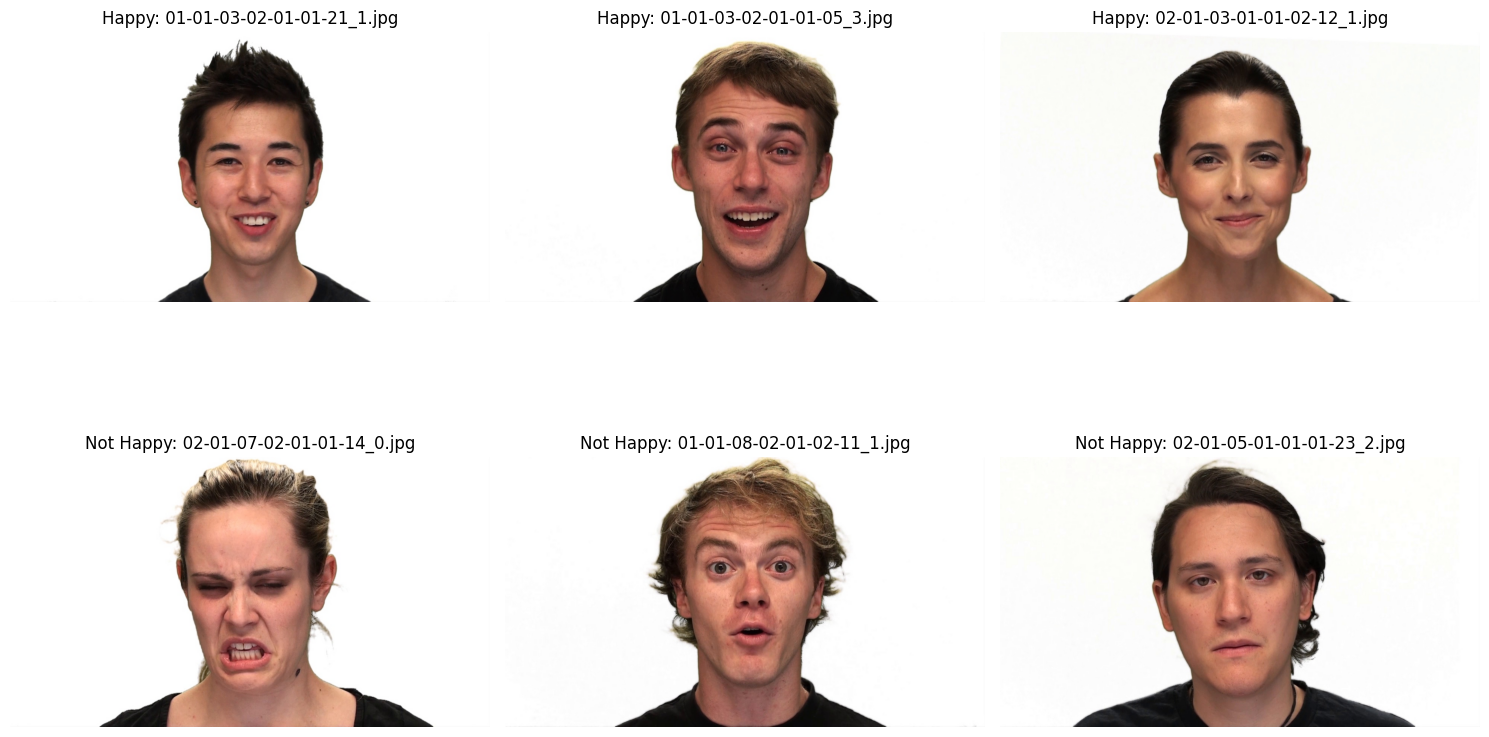

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

# Get a list of all frame files
all_frame_files = [f for f in os.listdir(frame_dir) if f.endswith('.jpg')]

# Filter for 'happy' frames (emotion code '03') and 'not happy' frames
happy_frames = []
not_happy_frames = []

for f in all_frame_files:
    parts = f.split('-')
    if len(parts) > 2:
        emotion_code = parts[2]
        if emotion_code == '03':
            happy_frames.append(f)
        else:
            not_happy_frames.append(f)

# Select 3 random happy frames
selected_happy_frames = random.sample(happy_frames, min(3, len(happy_frames)))
if not selected_happy_frames:
    print("No 'happy' frames found in the directory.")

# Select 3 random not happy frames
selected_not_happy_frames = random.sample(not_happy_frames, min(3, len(not_happy_frames)))
if not selected_not_happy_frames:
    print("No 'not happy' frames found in the directory.")

# Combine for display in 2 rows
all_frames_to_display = selected_happy_frames + selected_not_happy_frames

if all_frames_to_display:
    plt.figure(figsize=(15, 10)) # Adjust figure size for 2 rows

    # Plot Happy Frames (first row)
    for i, frame_name in enumerate(selected_happy_frames):
        img_path = os.path.join(frame_dir, frame_name)
        img = Image.open(img_path)

        plt.subplot(2, 3, i + 1) # 2 rows, 3 columns, position i+1
        plt.imshow(img)
        plt.title(f"Happy: {frame_name}")
        plt.axis('off')

    # Plot Not Happy Frames (second row)
    for i, frame_name in enumerate(selected_not_happy_frames):
        img_path = os.path.join(frame_dir, frame_name)
        img = Image.open(img_path)

        plt.subplot(2, 3, i + 4) # 2 rows, 3 columns, position i+4 (for second row)
        plt.imshow(img)
        plt.title(f"Not Happy: {frame_name}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No frames selected for display.")

# PIPELINE

##**9. Full Pipeline: KFOLD TRAINING + VALIDATION ----> TESTING**

Using device: cpu
Total data for K-Fold (train_val_data): 1865 samples
Total final holdout test data (test_data): 467 samples
                 Training ResNet18                    

--- Fold 1/5 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


  Epoch 1/15 | Train Loss: 0.3578 Acc: 82.77% | Val Loss: 0.3155 Acc: 89.01%
  Epoch 2/15 | Train Loss: 0.1965 Acc: 92.63% | Val Loss: 0.3192 Acc: 86.86%
  Epoch 3/15 | Train Loss: 0.1584 Acc: 93.36% | Val Loss: 0.2360 Acc: 93.03%
  Epoch 4/15 | Train Loss: 0.1163 Acc: 95.31% | Val Loss: 0.1867 Acc: 94.37%
  Epoch 5/15 | Train Loss: 0.0809 Acc: 97.18% | Val Loss: 0.2664 Acc: 93.03%
  Epoch 6/15 | Train Loss: 0.0751 Acc: 97.59% | Val Loss: 0.2842 Acc: 93.03%
  Epoch 7/15 | Train Loss: 0.0568 Acc: 97.86% | Val Loss: 0.1481 Acc: 95.44%
  Epoch 8/15 | Train Loss: 0.0744 Acc: 97.39% | Val Loss: 0.2347 Acc: 93.03%
  Epoch 9/15 | Train Loss: 0.0481 Acc: 98.26% | Val Loss: 0.2298 Acc: 93.30%
  Epoch 10/15 | Train Loss: 0.0443 Acc: 98.26% | Val Loss: 0.2486 Acc: 93.30%
  Early stopping triggered at epoch 10


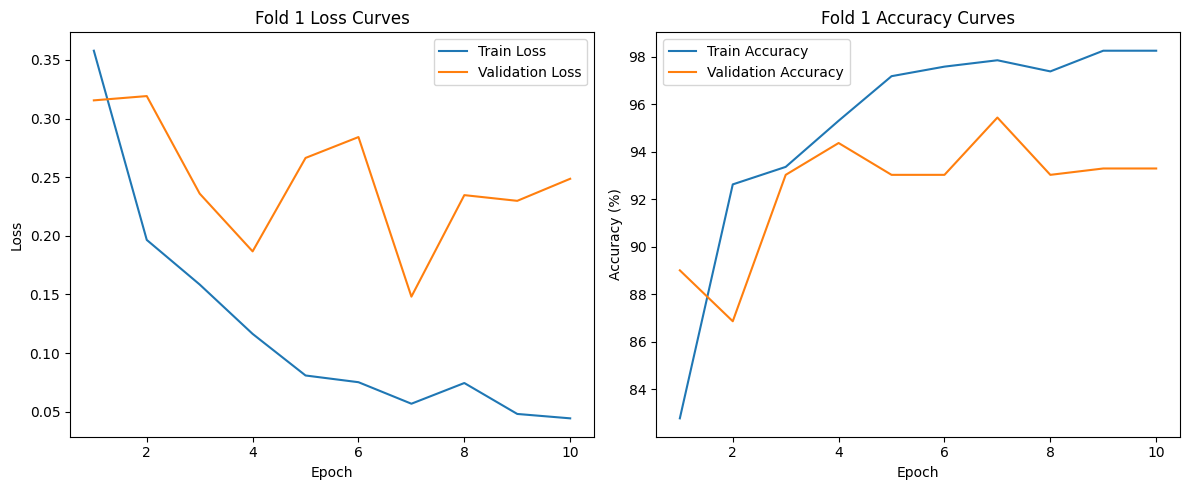


--- Validation Metrics (Fold 1) ---
Accuracy: 93.30%
Precision: 0.9765
Recall: 0.8877
F1-score: 0.9300

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       186
           1       0.98      0.89      0.93       187

    accuracy                           0.93       373
   macro avg       0.94      0.93      0.93       373
weighted avg       0.94      0.93      0.93       373



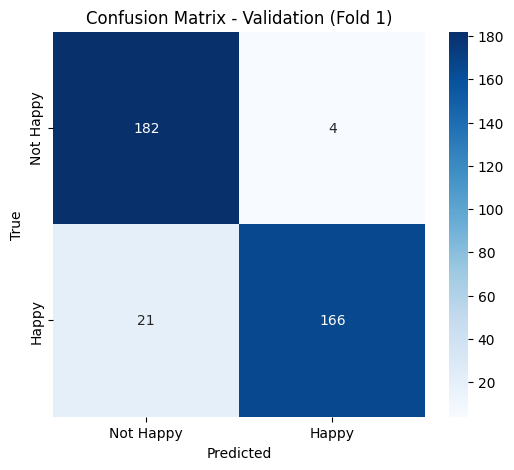

Fold 1 training complete. Best Validation Loss: 0.1481

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1/15 | Train Loss: 0.3800 Acc: 81.37% | Val Loss: 0.3131 Acc: 84.45%
  Epoch 2/15 | Train Loss: 0.1952 Acc: 93.03% | Val Loss: 0.2231 Acc: 91.42%
  Epoch 3/15 | Train Loss: 0.1584 Acc: 93.43% | Val Loss: 0.1897 Acc: 93.83%
  Epoch 4/15 | Train Loss: 0.1277 Acc: 95.24% | Val Loss: 0.3907 Acc: 83.38%
  Epoch 5/15 | Train Loss: 0.1041 Acc: 95.84% | Val Loss: 0.1204 Acc: 94.37%
  Epoch 6/15 | Train Loss: 0.0755 Acc: 97.12% | Val Loss: 0.7471 Acc: 71.58%
  Epoch 7/15 | Train Loss: 0.1085 Acc: 96.11% | Val Loss: 0.1347 Acc: 94.37%
  Epoch 8/15 | Train Loss: 0.0604 Acc: 98.12% | Val Loss: 0.1256 Acc: 96.51%
  Early stopping triggered at epoch 8


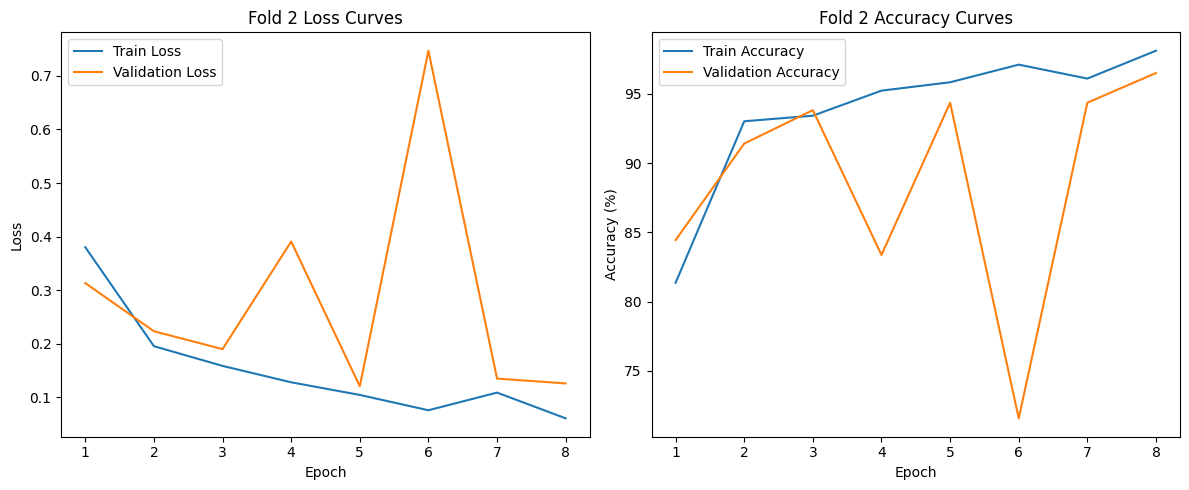


--- Validation Metrics (Fold 2) ---
Accuracy: 96.51%
Precision: 0.9485
Recall: 0.9840
F1-score: 0.9659

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       186
           1       0.95      0.98      0.97       187

    accuracy                           0.97       373
   macro avg       0.97      0.97      0.97       373
weighted avg       0.97      0.97      0.97       373



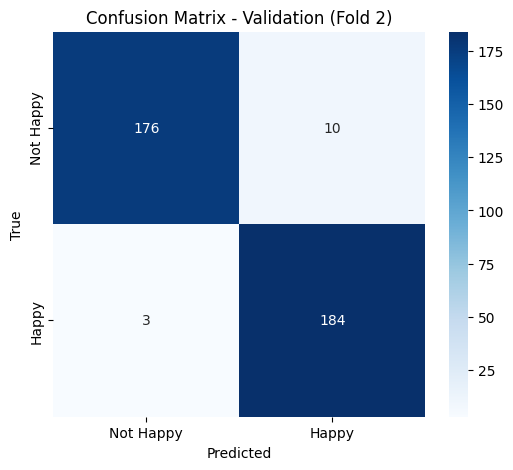

Fold 2 training complete. Best Validation Loss: 0.1204

--- Fold 3/5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1/15 | Train Loss: 0.3714 Acc: 82.84% | Val Loss: 0.1741 Acc: 92.76%
  Epoch 2/15 | Train Loss: 0.2013 Acc: 92.29% | Val Loss: 0.1568 Acc: 93.30%
  Epoch 3/15 | Train Loss: 0.1437 Acc: 94.24% | Val Loss: 0.0934 Acc: 97.32%
  Epoch 4/15 | Train Loss: 0.1241 Acc: 95.31% | Val Loss: 0.0745 Acc: 98.12%
  Epoch 5/15 | Train Loss: 0.1031 Acc: 96.58% | Val Loss: 0.1342 Acc: 93.83%
  Epoch 6/15 | Train Loss: 0.0888 Acc: 96.31% | Val Loss: 0.1064 Acc: 96.25%
  Epoch 7/15 | Train Loss: 0.0813 Acc: 96.92% | Val Loss: 0.1186 Acc: 96.51%
  Early stopping triggered at epoch 7


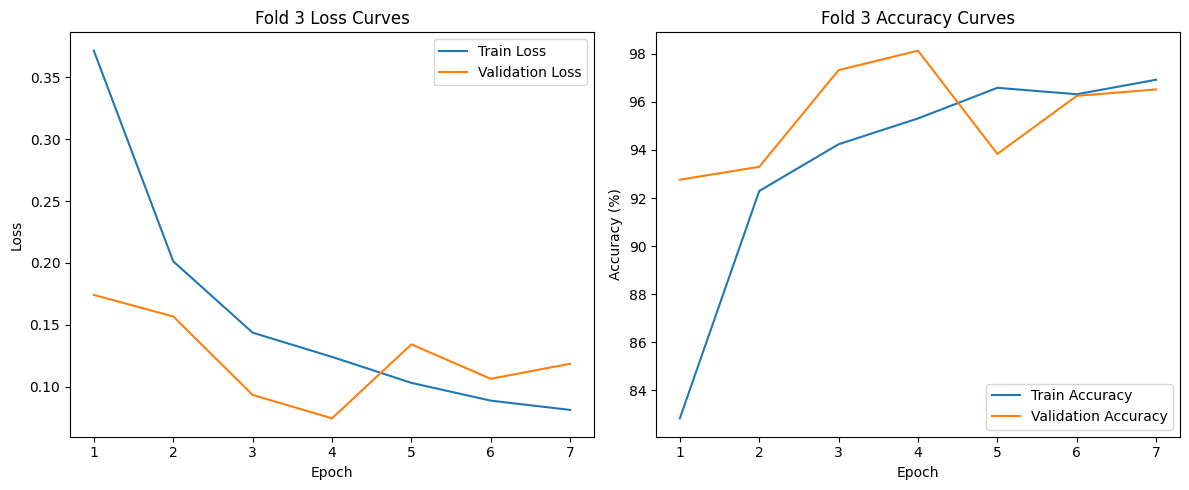


--- Validation Metrics (Fold 3) ---
Accuracy: 96.51%
Precision: 0.9439
Recall: 0.9893
F1-score: 0.9661

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96       186
           1       0.94      0.99      0.97       187

    accuracy                           0.97       373
   macro avg       0.97      0.97      0.97       373
weighted avg       0.97      0.97      0.97       373



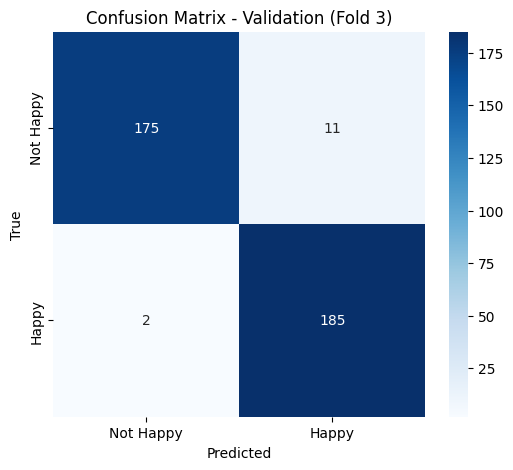

Fold 3 training complete. Best Validation Loss: 0.0745

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1/15 | Train Loss: 0.3664 Acc: 83.58% | Val Loss: 0.1601 Acc: 93.03%
  Epoch 2/15 | Train Loss: 0.1800 Acc: 93.36% | Val Loss: 0.4074 Acc: 86.86%
  Epoch 3/15 | Train Loss: 0.1630 Acc: 93.97% | Val Loss: 0.1372 Acc: 94.10%
  Epoch 4/15 | Train Loss: 0.1485 Acc: 94.57% | Val Loss: 0.1632 Acc: 94.91%
  Epoch 5/15 | Train Loss: 0.1168 Acc: 95.51% | Val Loss: 0.3953 Acc: 86.60%
  Epoch 6/15 | Train Loss: 0.0945 Acc: 96.45% | Val Loss: 0.1209 Acc: 95.44%
  Epoch 7/15 | Train Loss: 0.0753 Acc: 97.12% | Val Loss: 0.1104 Acc: 95.98%
  Epoch 8/15 | Train Loss: 0.0798 Acc: 97.18% | Val Loss: 0.0877 Acc: 96.78%
  Epoch 9/15 | Train Loss: 0.0670 Acc: 97.12% | Val Loss: 0.1834 Acc: 94.91%
  Epoch 10/15 | Train Loss: 0.0578 Acc: 97.92% | Val Loss: 0.0674 Acc: 97.05%
  Epoch 11/15 | Train Loss: 0.0711 Acc: 97.12% | Val Loss: 0.2467 Acc: 93.30%
  Epoch 12/15 | Train Loss: 0.0512 Acc: 98.19% | Val Loss: 0.0738 Acc: 97.05%
  Epoch 13/15 | Train Loss: 0.0359 Acc: 98.66% | Val Loss: 0.1066 Acc: 98

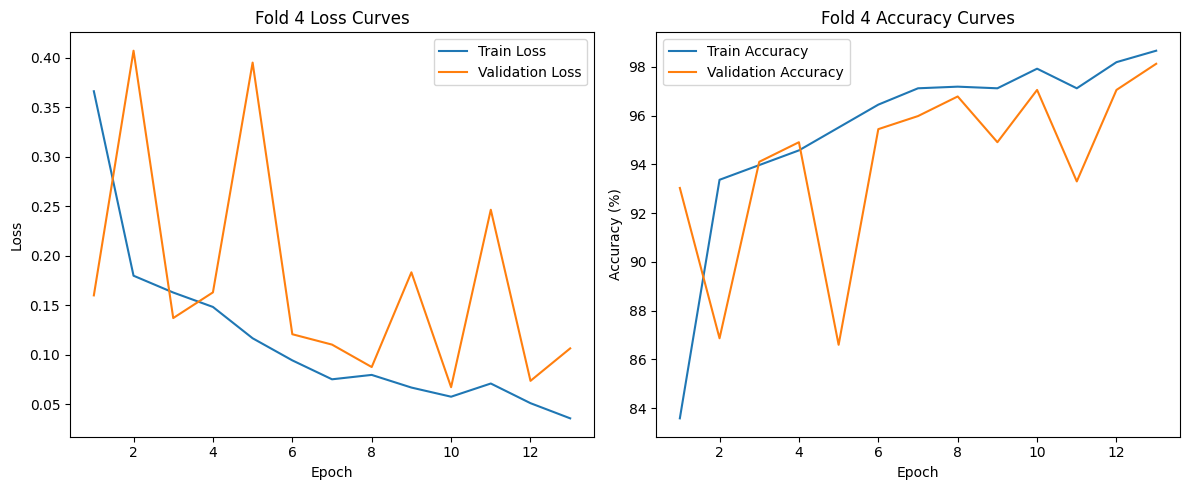


--- Validation Metrics (Fold 4) ---
Accuracy: 98.12%
Precision: 0.9637
Recall: 1.0000
F1-score: 0.9815

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       187
           1       0.96      1.00      0.98       186

    accuracy                           0.98       373
   macro avg       0.98      0.98      0.98       373
weighted avg       0.98      0.98      0.98       373



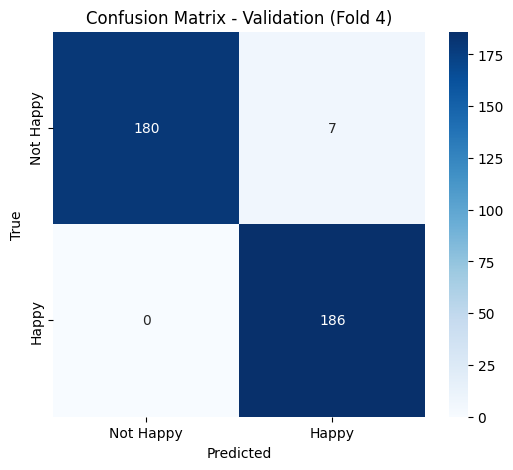

Fold 4 training complete. Best Validation Loss: 0.0674

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1/15 | Train Loss: 0.3677 Acc: 81.90% | Val Loss: 0.2276 Acc: 90.88%
  Epoch 2/15 | Train Loss: 0.1852 Acc: 92.49% | Val Loss: 0.1533 Acc: 94.91%
  Epoch 3/15 | Train Loss: 0.1502 Acc: 94.30% | Val Loss: 0.1288 Acc: 96.25%
  Epoch 4/15 | Train Loss: 0.1262 Acc: 94.97% | Val Loss: 0.1368 Acc: 94.64%
  Epoch 5/15 | Train Loss: 0.1113 Acc: 96.18% | Val Loss: 0.1103 Acc: 96.78%
  Epoch 6/15 | Train Loss: 0.0831 Acc: 96.98% | Val Loss: 0.1605 Acc: 95.44%
  Epoch 7/15 | Train Loss: 0.0799 Acc: 97.18% | Val Loss: 0.1266 Acc: 96.25%
  Epoch 8/15 | Train Loss: 0.0914 Acc: 96.58% | Val Loss: 0.2455 Acc: 90.35%
  Early stopping triggered at epoch 8


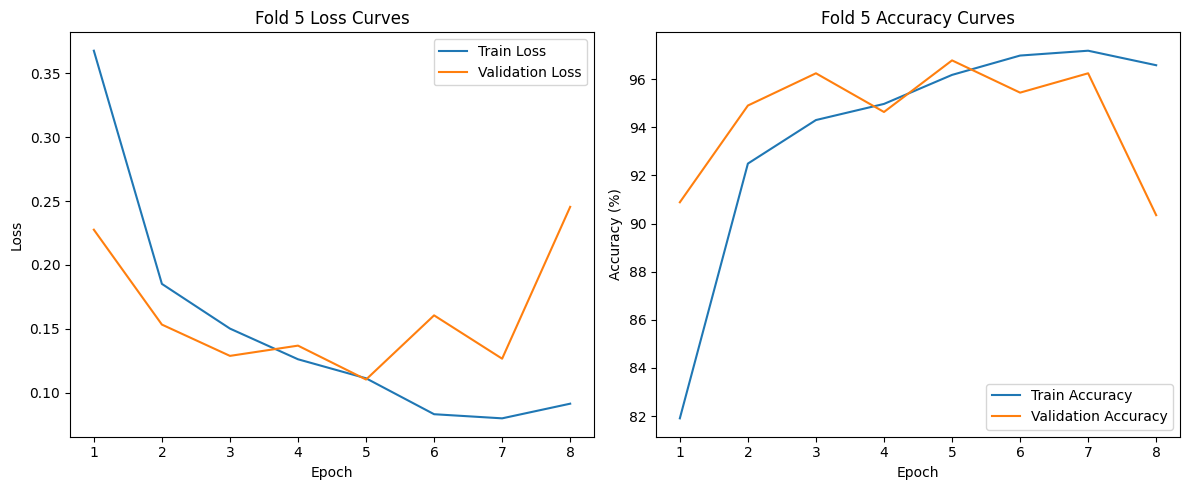


--- Validation Metrics (Fold 5) ---
Accuracy: 90.35%
Precision: 0.9934
Recall: 0.8118
F1-score: 0.8935

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.99      0.91       187
           1       0.99      0.81      0.89       186

    accuracy                           0.90       373
   macro avg       0.92      0.90      0.90       373
weighted avg       0.92      0.90      0.90       373



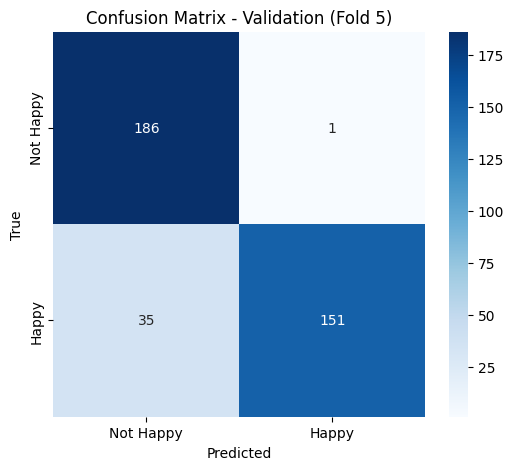

Fold 5 training complete. Best Validation Loss: 0.1103

               ResNet18 K-Fold Training Complete       

--- Final Evaluation of ResNet18 on Holdout Test Set ---
Loading best model from Fold 4 for final test evaluation.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Best ResNet18 model saved as ResNet18_best_model.pth

--- Final Test Metrics  ---
Accuracy: 96.15%
Precision: 0.9317
Recall: 0.9957
F1-score: 0.9627

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96       234
           1       0.93      1.00      0.96       233

    accuracy                           0.96       467
   macro avg       0.96      0.96      0.96       467
weighted avg       0.96      0.96      0.96       467



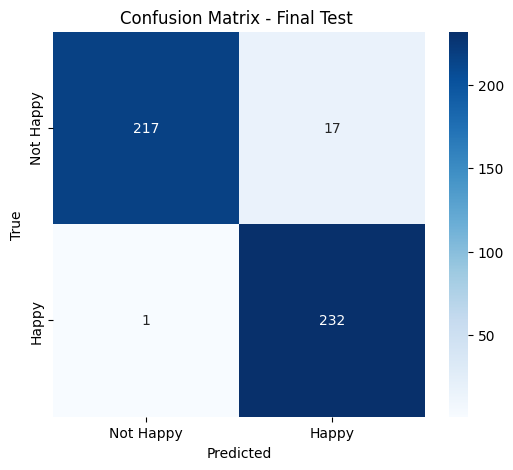

Final Test Loss: 0.1412, Final Test Accuracy: 96.15%

------------------------------------------------------------

                 Training MobileNetV2                    

--- Fold 1/5 ---
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:00<00:00, 114MB/s]


  Epoch 1/15 | Train Loss: 0.4027 Acc: 81.30% | Val Loss: 0.2793 Acc: 90.35%
  Epoch 2/15 | Train Loss: 0.1811 Acc: 92.96% | Val Loss: 0.2977 Acc: 86.86%
  Epoch 3/15 | Train Loss: 0.1281 Acc: 94.97% | Val Loss: 0.1905 Acc: 91.96%
  Epoch 4/15 | Train Loss: 0.1316 Acc: 94.84% | Val Loss: 0.2237 Acc: 93.30%
  Epoch 5/15 | Train Loss: 0.1165 Acc: 95.64% | Val Loss: 0.1790 Acc: 94.64%
  Epoch 6/15 | Train Loss: 0.0862 Acc: 96.65% | Val Loss: 0.1971 Acc: 94.10%
  Epoch 7/15 | Train Loss: 0.0666 Acc: 97.92% | Val Loss: 0.1564 Acc: 94.91%
  Epoch 8/15 | Train Loss: 0.0653 Acc: 97.65% | Val Loss: 0.2776 Acc: 93.57%
  Epoch 9/15 | Train Loss: 0.0593 Acc: 97.79% | Val Loss: 0.1830 Acc: 95.17%
  Epoch 10/15 | Train Loss: 0.0649 Acc: 97.59% | Val Loss: 0.2514 Acc: 94.64%
  Early stopping triggered at epoch 10


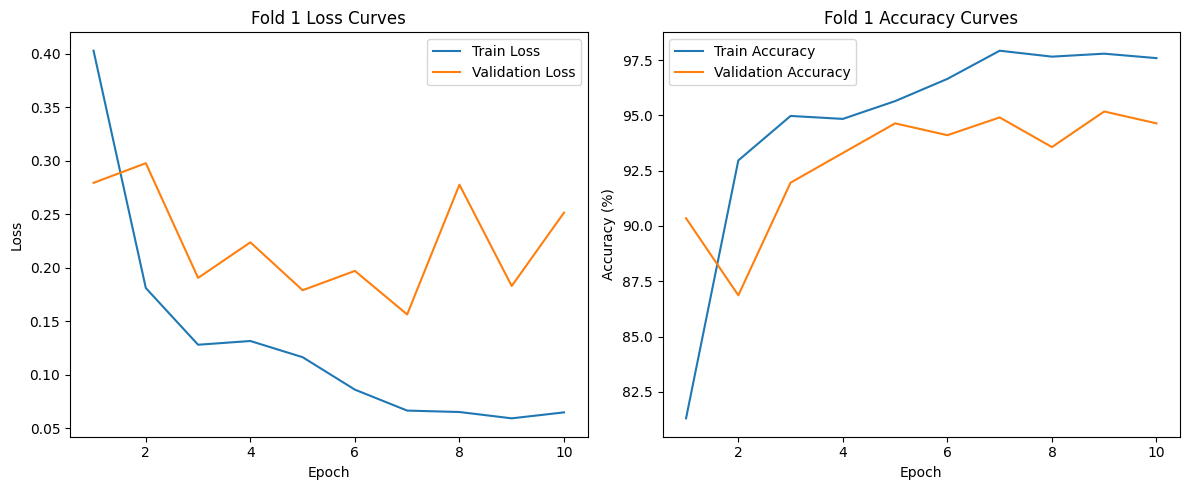


--- Validation Metrics (Fold 1) ---
Accuracy: 94.64%
Precision: 0.9196
Recall: 0.9786
F1-score: 0.9482

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.94       186
           1       0.92      0.98      0.95       187

    accuracy                           0.95       373
   macro avg       0.95      0.95      0.95       373
weighted avg       0.95      0.95      0.95       373



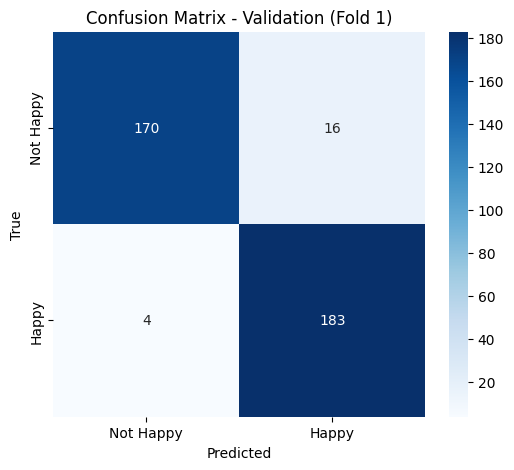

Fold 1 training complete. Best Validation Loss: 0.1564

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1/15 | Train Loss: 0.3598 Acc: 82.44% | Val Loss: 0.1811 Acc: 92.76%
  Epoch 2/15 | Train Loss: 0.2119 Acc: 91.62% | Val Loss: 0.2193 Acc: 89.81%
  Epoch 3/15 | Train Loss: 0.1709 Acc: 93.03% | Val Loss: 0.1144 Acc: 95.71%
  Epoch 4/15 | Train Loss: 0.1350 Acc: 94.97% | Val Loss: 0.2819 Acc: 88.20%
  Epoch 5/15 | Train Loss: 0.1258 Acc: 95.17% | Val Loss: 0.1003 Acc: 96.51%
  Epoch 6/15 | Train Loss: 0.0897 Acc: 96.45% | Val Loss: 0.1235 Acc: 96.25%
  Epoch 7/15 | Train Loss: 0.1049 Acc: 96.18% | Val Loss: 0.1063 Acc: 94.91%
  Epoch 8/15 | Train Loss: 0.0858 Acc: 96.98% | Val Loss: 0.0820 Acc: 96.78%
  Epoch 9/15 | Train Loss: 0.0548 Acc: 97.79% | Val Loss: 0.0808 Acc: 96.78%
  Epoch 10/15 | Train Loss: 0.0691 Acc: 97.18% | Val Loss: 0.0837 Acc: 97.32%
  Epoch 11/15 | Train Loss: 0.0651 Acc: 97.65% | Val Loss: 0.0964 Acc: 96.51%
  Epoch 12/15 | Train Loss: 0.0544 Acc: 97.59% | Val Loss: 0.0910 Acc: 96.25%
  Early stopping triggered at epoch 12


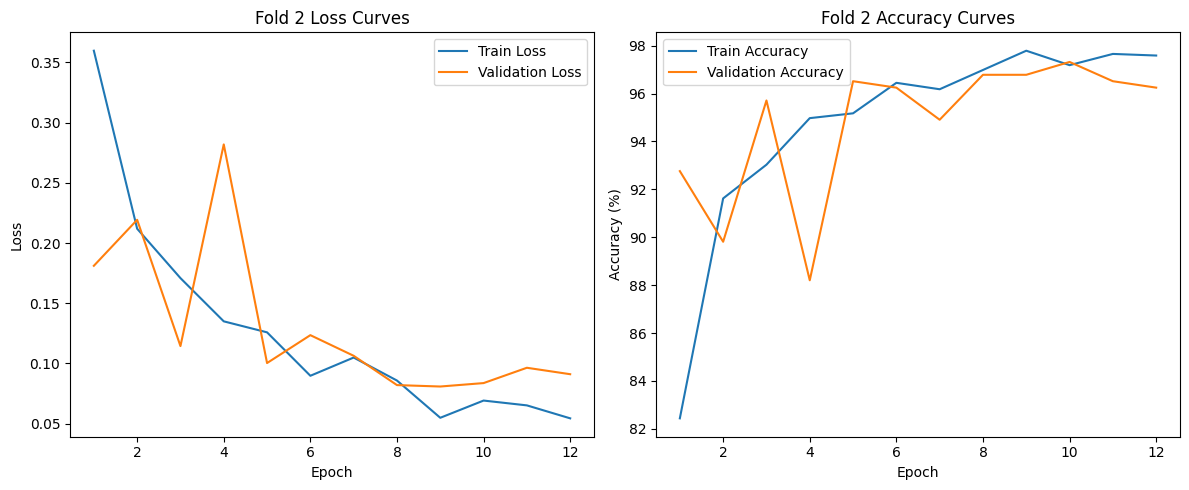


--- Validation Metrics (Fold 2) ---
Accuracy: 96.25%
Precision: 0.9391
Recall: 0.9893
F1-score: 0.9635

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96       186
           1       0.94      0.99      0.96       187

    accuracy                           0.96       373
   macro avg       0.96      0.96      0.96       373
weighted avg       0.96      0.96      0.96       373



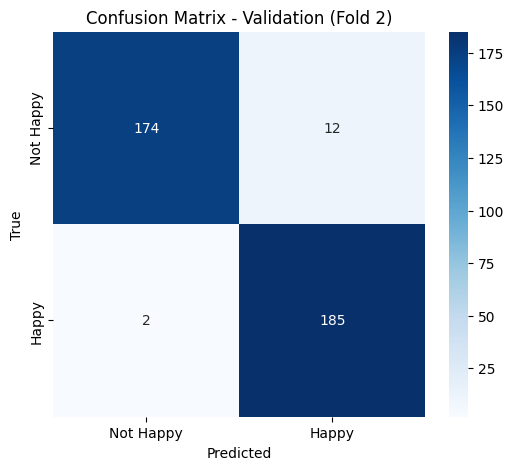

Fold 2 training complete. Best Validation Loss: 0.0808

--- Fold 3/5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1/15 | Train Loss: 0.4013 Acc: 79.49% | Val Loss: 0.1644 Acc: 94.91%
  Epoch 2/15 | Train Loss: 0.2121 Acc: 91.69% | Val Loss: 0.1374 Acc: 94.91%
  Epoch 3/15 | Train Loss: 0.1724 Acc: 93.30% | Val Loss: 0.1172 Acc: 95.98%
  Epoch 4/15 | Train Loss: 0.1202 Acc: 95.91% | Val Loss: 0.3144 Acc: 88.47%
  Epoch 5/15 | Train Loss: 0.1244 Acc: 95.38% | Val Loss: 0.1576 Acc: 93.30%
  Epoch 6/15 | Train Loss: 0.1088 Acc: 95.31% | Val Loss: 0.1313 Acc: 94.64%
  Early stopping triggered at epoch 6


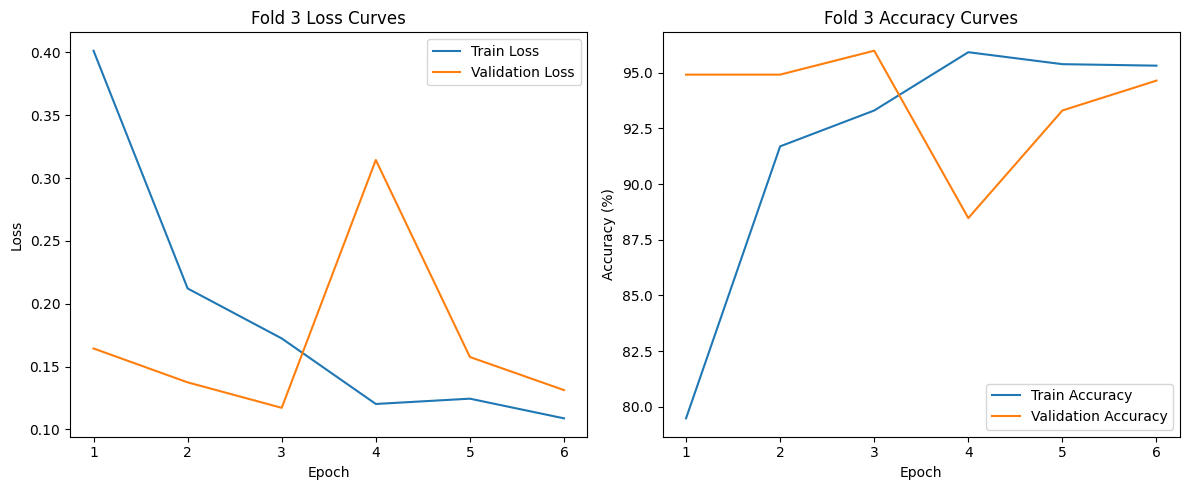


--- Validation Metrics (Fold 3) ---
Accuracy: 94.64%
Precision: 0.9034
Recall: 1.0000
F1-score: 0.9492

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94       186
           1       0.90      1.00      0.95       187

    accuracy                           0.95       373
   macro avg       0.95      0.95      0.95       373
weighted avg       0.95      0.95      0.95       373



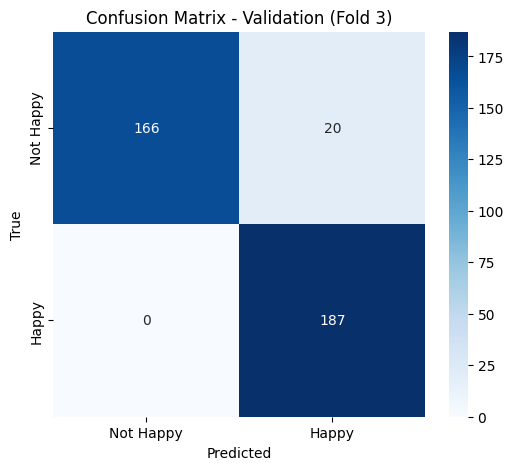

Fold 3 training complete. Best Validation Loss: 0.1172

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1/15 | Train Loss: 0.4056 Acc: 82.17% | Val Loss: 0.2252 Acc: 90.35%
  Epoch 2/15 | Train Loss: 0.2160 Acc: 90.95% | Val Loss: 0.1392 Acc: 95.71%
  Epoch 3/15 | Train Loss: 0.1560 Acc: 94.37% | Val Loss: 0.1414 Acc: 93.57%
  Epoch 4/15 | Train Loss: 0.1316 Acc: 95.11% | Val Loss: 0.1134 Acc: 95.98%
  Epoch 5/15 | Train Loss: 0.1328 Acc: 94.84% | Val Loss: 0.0760 Acc: 97.05%
  Epoch 6/15 | Train Loss: 0.1234 Acc: 95.84% | Val Loss: 0.0798 Acc: 97.32%
  Epoch 7/15 | Train Loss: 0.0981 Acc: 96.51% | Val Loss: 0.0682 Acc: 97.05%
  Epoch 8/15 | Train Loss: 0.0998 Acc: 95.64% | Val Loss: 0.1291 Acc: 94.91%
  Epoch 9/15 | Train Loss: 0.0727 Acc: 97.86% | Val Loss: 0.1226 Acc: 96.51%
  Epoch 10/15 | Train Loss: 0.0570 Acc: 97.86% | Val Loss: 0.0469 Acc: 98.12%
  Epoch 11/15 | Train Loss: 0.0527 Acc: 98.26% | Val Loss: 0.0506 Acc: 97.59%
  Epoch 12/15 | Train Loss: 0.0408 Acc: 98.59% | Val Loss: 0.0372 Acc: 98.93%
  Epoch 13/15 | Train Loss: 0.0514 Acc: 98.19% | Val Loss: 0.0622 Acc: 97

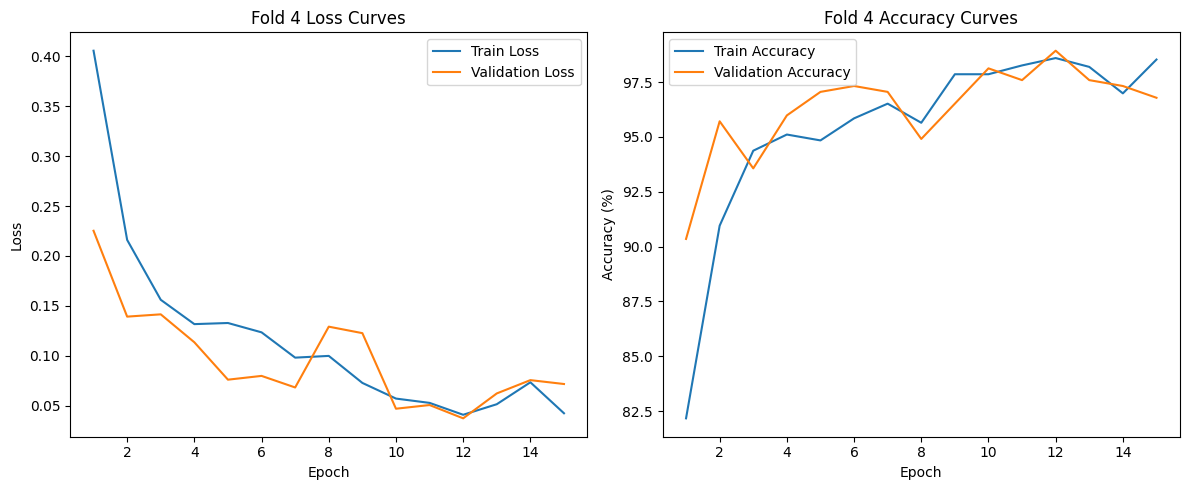


--- Validation Metrics (Fold 4) ---
Accuracy: 96.78%
Precision: 0.9394
Recall: 1.0000
F1-score: 0.9688

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97       187
           1       0.94      1.00      0.97       186

    accuracy                           0.97       373
   macro avg       0.97      0.97      0.97       373
weighted avg       0.97      0.97      0.97       373



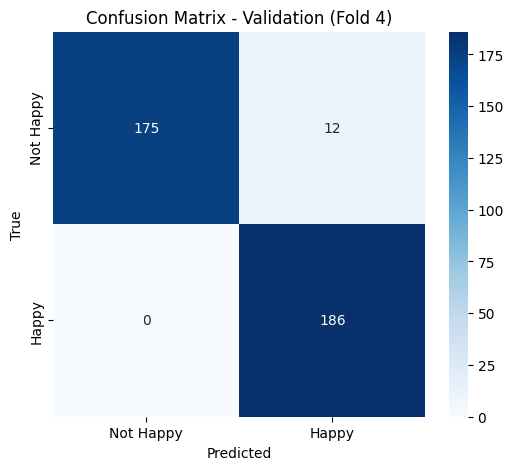

Fold 4 training complete. Best Validation Loss: 0.0372

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1/15 | Train Loss: 0.4179 Acc: 80.09% | Val Loss: 0.2219 Acc: 90.08%
  Epoch 2/15 | Train Loss: 0.2032 Acc: 91.55% | Val Loss: 0.2277 Acc: 91.15%
  Epoch 3/15 | Train Loss: 0.1780 Acc: 93.10% | Val Loss: 0.1633 Acc: 93.30%
  Epoch 4/15 | Train Loss: 0.1233 Acc: 95.04% | Val Loss: 0.1421 Acc: 94.64%
  Epoch 5/15 | Train Loss: 0.0925 Acc: 96.72% | Val Loss: 0.2063 Acc: 93.57%
  Epoch 6/15 | Train Loss: 0.1033 Acc: 96.45% | Val Loss: 0.1099 Acc: 96.51%
  Epoch 7/15 | Train Loss: 0.1211 Acc: 95.44% | Val Loss: 0.0968 Acc: 97.05%
  Epoch 8/15 | Train Loss: 0.0630 Acc: 97.65% | Val Loss: 0.1053 Acc: 94.64%
  Epoch 9/15 | Train Loss: 0.0625 Acc: 97.92% | Val Loss: 0.1616 Acc: 95.17%
  Epoch 10/15 | Train Loss: 0.0667 Acc: 97.45% | Val Loss: 0.1314 Acc: 93.83%
  Early stopping triggered at epoch 10


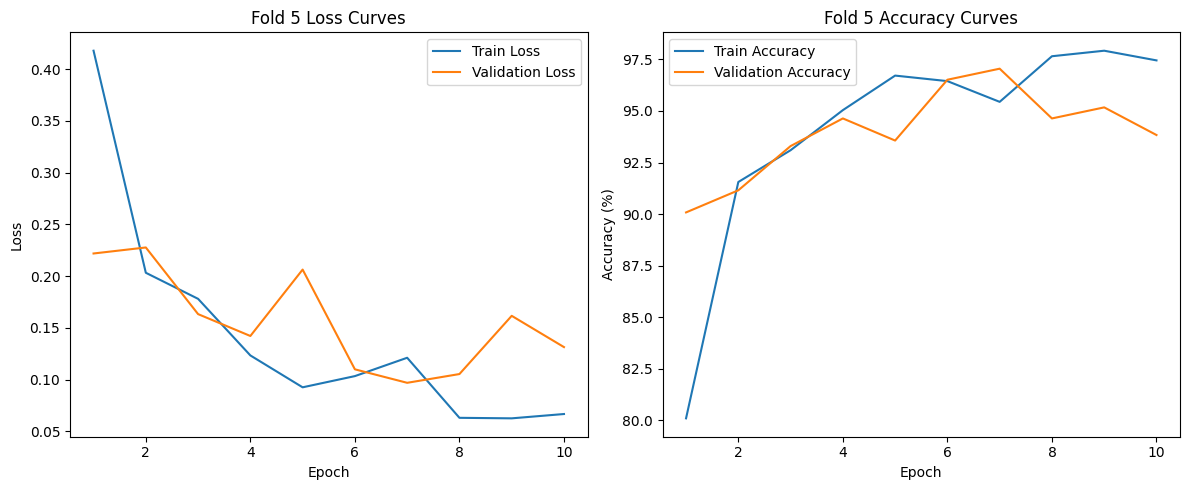


--- Validation Metrics (Fold 5) ---
Accuracy: 93.83%
Precision: 0.9711
Recall: 0.9032
F1-score: 0.9359

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       187
           1       0.97      0.90      0.94       186

    accuracy                           0.94       373
   macro avg       0.94      0.94      0.94       373
weighted avg       0.94      0.94      0.94       373



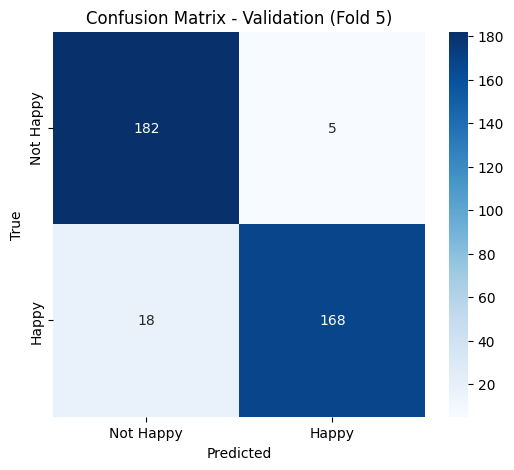

Fold 5 training complete. Best Validation Loss: 0.0968

               MobileNetV2 K-Fold Training Complete       

--- Final Evaluation of MobileNetV2 on Holdout Test Set ---
Loading best model from Fold 4 for final test evaluation.
Best MobileNetV2 model saved as MobileNetV2_best_model.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Final Test Metrics  ---
Accuracy: 96.36%
Precision: 0.9463
Recall: 0.9828
F1-score: 0.9642

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96       234
           1       0.95      0.98      0.96       233

    accuracy                           0.96       467
   macro avg       0.96      0.96      0.96       467
weighted avg       0.96      0.96      0.96       467



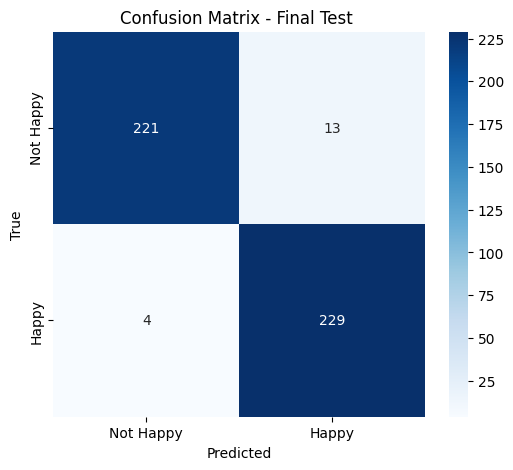

Final Test Loss: 0.1007, Final Test Accuracy: 96.36%

--- Summary of K-Fold Cross-Validation Results ---
ResNet18 K-Fold Results: [{'fold': 1, 'best_val_loss': 0.14810527969772616, 'final_val_accuracy': 93.2975871313673, 'final_val_precision': 0.9764705882352941, 'final_val_recall': 0.8877005347593583, 'final_val_f1': 0.9299719887955182}, {'fold': 2, 'best_val_loss': 0.12038689494753878, 'final_val_accuracy': 96.51474530831099, 'final_val_precision': 0.9484536082474226, 'final_val_recall': 0.983957219251337, 'final_val_f1': 0.9658792650918635}, {'fold': 3, 'best_val_loss': 0.07446433661971241, 'final_val_accuracy': 96.51474530831099, 'final_val_precision': 0.9438775510204082, 'final_val_recall': 0.9893048128342246, 'final_val_f1': 0.9660574412532638}, {'fold': 4, 'best_val_loss': 0.06737369174758594, 'final_val_accuracy': 98.12332439678283, 'final_val_precision': 0.9637305699481865, 'final_val_recall': 1.0, 'final_val_f1': 0.9815303430079155}, {'fold': 5, 'best_val_loss': 0.11029095140

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from sklearn.model_selection import StratifiedKFold
from PIL import Image
import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

# The RAVDESSFrames Dataset class is already defined in cell HQO7l7MTAiIf and its execution is expected prior to this cell.
# Therefore, removing the duplicate definition from here.

# Helper function to compute and display metrics and plots
def evaluate_and_log_metrics(true_labels, predicted_labels, phase_name, fold_idx=None):
    """
    Computes and logs detailed classification metrics, including confusion matrix.
    """
    print(f"\n--- {phase_name} Metrics {'(Fold ' + str(fold_idx) + ')' if fold_idx else ''} ---")
    acc = accuracy_score(true_labels, predicted_labels)
    # Using 'binary' for average, as it's a binary classification problem (happy vs not happy)
    # zero_division=0 handles cases where a class has no true or predicted samples to avoid warnings/errors
    prec = precision_score(true_labels, predicted_labels, average='binary', zero_division=0)
    rec = recall_score(true_labels, predicted_labels, average='binary', zero_division=0)
    f1 = f1_score(true_labels, predicted_labels, average='binary', zero_division=0)
    cm = confusion_matrix(true_labels, predicted_labels)

    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(true_labels, predicted_labels, zero_division=0))

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Happy", "Happy"], yticklabels=["Not Happy", "Happy"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {phase_name} {'(Fold ' + str(fold_idx) + ')' if fold_idx else ''}")
    plt.show()

    return acc, prec, rec, f1

# Define a reusable training function with K-Fold Cross-Validation
def train_model_with_kfold(model_arch, model_name, kfold_dataset_data, final_test_data,
                           train_transform, val_test_transform, device,
                           num_folds=5, num_epochs=15, patience=3, batch_size=32, lr=1e-4):
    """
    Trains a model using K-Fold Cross-Validation and evaluates on a separate test set.
    Includes detailed metrics and plots for each validation fold and the final test set.

    Args:
        model_arch: The model architecture (e.g., models.resnet18, models.mobilenet_v2).
        model_name (str): Name of the model for logging and saving.
        kfold_dataset_data (list): List of (image_path, label) tuples for K-Fold. (Will use train_val_data)
        final_test_data (list): List of (image_path, label) tuples for the final holdout test set. (Will use test_data)
        train_transform: Transforms to apply to training data (with augmentation).
        val_test_transform: Transforms to apply to validation and test data (without augmentation).
        device (torch.device): Device to train on (cuda or cpu).
        num_folds (int): Number of folds for K-Fold cross-validation.
        num_epochs (int): Maximum number of epochs for each fold.
        patience (int): Early stopping patience.
        batch_size (int): Batch size for DataLoaders.
        lr (float): Learning rate for the optimizer.
    """
    print(f"============================================================")
    print(f"                 Training {model_name}                    ")
    print(f"============================================================")

    # Extract labels for StratifiedKFold
    # Ensure kfold_dataset_data contains (image_path, label) tuples
    kfold_labels = [label for _, label in kfold_dataset_data]

    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_results = []
    best_overall_model_state = None
    best_overall_val_loss = float('inf')
    best_overall_fold_idx = -1

    # Create the final holdout test dataset and loader
    # Assuming RAVDESSFrames class is accessible globally or defined in a previous cell
    final_test_dataset = RAVDESSFrames(final_test_data, transform=val_test_transform)
    final_test_loader = DataLoader(final_test_dataset, batch_size=batch_size, shuffle=False)

    for fold, (train_ids, val_ids) in enumerate(kf.split(kfold_dataset_data, kfold_labels)):
        print(f"\n--- Fold {fold+1}/{num_folds} ---")

        # Create actual datasets for the current fold with appropriate transforms
        train_subset_data = [kfold_dataset_data[i] for i in train_ids]
        val_subset_data = [kfold_dataset_data[i] for i in val_ids]

        train_dataset = RAVDESSFrames(train_subset_data, transform=train_transform)
        val_dataset = RAVDESSFrames(val_subset_data, transform=val_test_transform)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Initialize model for current fold
        model = model_arch(pretrained=True)
        # Adjust final classification layer based on model type
        if isinstance(model, models.ResNet): # ResNet-like models (ResNet18, ResNet50, etc.)
            model.fc = nn.Linear(model.fc.in_features, 2)
        elif isinstance(model, models.MobileNetV2): # MobileNetV2
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
        else:
            print(f"Warning: Final layer modification not explicitly handled for {model_name}. Please verify manually.")
            if hasattr(model, 'fc'):
                model.fc = nn.Linear(model.fc.in_features, 2)
            elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential) and len(model.classifier) > 1:
                model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)
            else:
                raise ValueError(f"Could not automatically identify final layer for {model_name}")

        model = model.to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

        # Early stopping variables
        best_fold_val_loss = float('inf')
        epochs_no_improve = 0
        current_fold_best_model_state = None

        # Lists to store metrics for plotting curves
        train_losses = []
        train_accuracies = []
        val_losses = []
        val_accuracies = []

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            correct_train = 0
            total_train = 0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()

            train_loss = running_loss / len(train_loader)
            train_accuracy = 100 * correct_train / total_train

            model.eval()
            val_loss = 0.0
            correct_val = 0
            total_val = 0
            all_val_labels = []
            all_val_preds = []
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    total_val += labels.size(0)
                    correct_val += (predicted == labels).sum().item()
                    all_val_labels.extend(labels.cpu().numpy())
                    all_val_preds.extend(predicted.cpu().numpy())

            val_loss /= len(val_loader)
            val_accuracy = 100 * correct_val / total_val

            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)

            print(f"  Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_accuracy:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_accuracy:.2f}%")

            scheduler.step(val_loss) # Update learning rate based on validation loss

            # Early stopping check
            if val_loss < best_fold_val_loss:
                best_fold_val_loss = val_loss
                epochs_no_improve = 0
                current_fold_best_model_state = model.state_dict()
                # Update overall best model state if this fold's best is better
                if best_fold_val_loss < best_overall_val_loss:
                    best_overall_val_loss = best_fold_val_loss
                    best_overall_model_state = model.state_dict()
                    best_overall_fold_idx = fold
            else:
                epochs_no_improve += 1
                if epochs_no_improve == patience:
                    print(f"  Early stopping triggered at epoch {epoch+1}")
                    break

        # Plot Accuracy/Loss Curves for the current fold
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
        plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
        plt.title(f'Fold {fold+1} Loss Curves')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy')
        plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
        plt.title(f'Fold {fold+1} Accuracy Curves')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Evaluate and log detailed metrics for the validation set of the current fold
        fold_acc, fold_prec, fold_rec, fold_f1 = evaluate_and_log_metrics(all_val_labels, all_val_preds, "Validation", fold + 1)

        fold_results.append({
            "fold": fold + 1,
            "best_val_loss": best_fold_val_loss,
            "final_val_accuracy": fold_acc * 100, # Using accuracy from detailed metrics
            "final_val_precision": fold_prec,
            "final_val_recall": fold_rec,
            "final_val_f1": fold_f1
        })
        print(f"Fold {fold+1} training complete. Best Validation Loss: {best_fold_val_loss:.4f}")

    print(f"\n============================================================")
    print(f"               {model_name} K-Fold Training Complete       ")
    print(f"============================================================")

    # Final evaluation on the separate test set using the overall best model found during K-Fold
    print(f"\n--- Final Evaluation of {model_name} on Holdout Test Set ---")
    if best_overall_model_state:
        print(f"Loading best model from Fold {best_overall_fold_idx + 1} for final test evaluation.")
        model = model_arch(pretrained=True)
        if isinstance(model, models.ResNet):
            model.fc = nn.Linear(model.fc.in_features, 2)
        elif isinstance(model, models.MobileNetV2):
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
        model.load_state_dict(best_overall_model_state)
        model = model.to(device)
        model.eval() # Set model to evaluation mode

        torch.save(best_overall_model_state, f"{model_name}_best_model.pth")
        print(f"Best {model_name} model saved as {model_name}_best_model.pth")

        criterion = nn.CrossEntropyLoss() # Redefine criterion for final evaluation
        test_loss = 0.0
        all_test_labels = []
        all_test_preds = []
        with torch.no_grad():
            for images, labels in final_test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                all_test_labels.extend(labels.cpu().numpy())
                all_test_preds.extend(predicted.cpu().numpy())

        test_loss /= len(final_test_loader)

        # Evaluate and log detailed metrics for the final test set
        test_acc, test_prec, test_rec, test_f1 = evaluate_and_log_metrics(all_test_labels, all_test_preds, "Final Test")

        print(f"Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_acc*100:.2f}%")
        fold_results.append({"final_test_loss": test_loss, "final_test_accuracy": test_acc * 100,
                             "final_test_precision": test_prec, "final_test_recall": test_rec, "final_test_f1": test_f1})
    else:
        print("No overall best model state found during K-Fold. Skipping final test evaluation.")

    return fold_results

# --- Main Execution ---

# These variables are expected to be available from previous cells (e.g., HQO7l7MTAiIf, 3d4d1100):
# - RAVDESSFrames (class definition)
# - train_val_data (list of (path, label) tuples for K-Fold)
# - test_data (list of (path, label) tuples for the final holdout test set)
# - train_transform (transforms with augmentation)
# - val_test_transform (transforms without augmentation)
# - device (torch.device, e.g., 'cuda' or 'cpu')

# Ensure device is defined, as it might not be if previous cells are skipped or re-executed selectively.
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The RAVDESSFrames class is expected to be defined in a prior cell, e.g., HQO7l7MTAiIf
# If not, you might need to re-run cell HQO7l7MTAiIf or define it here.
# For this execution, assuming it is defined and accessible.

print(f"Using device: {device}") # Confirm device
# Using train_val_data for K-Fold as requested
print(f"Total data for K-Fold (train_val_data): {len(train_val_data)} samples")
# Using test_data for final holdout test as requested
print(f"Total final holdout test data (test_data): {len(test_data)} samples")

# ResNet18 Training
resnet18_kfold_results = train_model_with_kfold(
    model_arch=models.resnet18,
    model_name="ResNet18",
    kfold_dataset_data=train_val_data,   # Use train_val_data for K-Fold
    final_test_data=test_data,     # Use test_data for final evaluation
    train_transform=train_transform,
    val_test_transform=val_test_transform,
    device=device,
    num_folds=5,
    num_epochs=15,
    patience=3
)

print("\n" + "-" * 60 + "\n") # Separator for clarity

# MobileNetV2 Training
mobilenet_kfold_results = train_model_with_kfold(
    model_arch=models.mobilenet_v2,
    model_name="MobileNetV2",
    kfold_dataset_data=train_val_data, # Use train_val_data for K-Fold
    final_test_data=test_data,     # Use test_data for final evaluation
    train_transform=train_transform,
    val_test_transform=val_test_transform,
    device=device,
    num_folds=5,
    num_epochs=15,
    patience=3
)

print("\n--- Summary of K-Fold Cross-Validation Results ---")
print("ResNet18 K-Fold Results:", resnet18_kfold_results)
print("MobileNetV2 K-Fold Results:", mobilenet_kfold_results)

# Optional: Further analysis of results, e.g., averaging fold metrics
# Ensure there are results before attempting to average
print("\n" + "=" * 60)
print("               Comparative Results Summary          ")
print("=" * 60)

# Prepare data for a simple comparison table
results_table = []
headers = ["Model", "Avg Val Acc", "Avg Val Prec", "Avg Val Rec", "Avg Val F1", "Final Test Acc", "Final Test Prec", "Final Test Rec", "Final Test F1"]

if resnet18_kfold_results and len(resnet18_kfold_results) > 1: # Check if there are fold results and a final test result
    # Exclude the last element which is the final test result
    fold_metrics = resnet18_kfold_results[:-1]
    final_test_metrics = resnet18_kfold_results[-1]

    avg_resnet_val_acc = np.mean([r["final_val_accuracy"] for r in fold_metrics])
    avg_resnet_val_prec = np.mean([r["final_val_precision"] for r in fold_metrics])
    avg_resnet_val_rec = np.mean([r["final_val_recall"] for r in fold_metrics])
    avg_resnet_val_f1 = np.mean([r["final_val_f1"] for r in fold_metrics])

    results_table.append([
        "ResNet18",
        f"{avg_resnet_val_acc:.2f}%",
        f"{avg_resnet_val_prec:.4f}",
        f"{avg_resnet_val_rec:.4f}",
        f"{avg_resnet_val_f1:.4f}",
        f"{final_test_metrics['final_test_accuracy']:.2f}%",
        f"{final_test_metrics['final_test_precision']:.4f}",
        f"{final_test_metrics['final_test_recall']:.4f}",
        f"{final_test_metrics['final_test_f1']:.4f}"
    ])

if mobilenet_kfold_results and len(mobilenet_kfold_results) > 1:
    # Exclude the last element which is the final test result
    fold_metrics = mobilenet_kfold_results[:-1]
    final_test_metrics = mobilenet_kfold_results[-1]

    avg_mobilenet_val_acc = np.mean([r["final_val_accuracy"] for r in fold_metrics])
    avg_mobilenet_val_prec = np.mean([r["final_val_precision"] for r in fold_metrics])
    avg_mobilenet_val_rec = np.mean([r["final_val_recall"] for r in fold_metrics])
    avg_mobilenet_val_f1 = np.mean([r["final_val_f1"] for r in fold_metrics])

    results_table.append([
        "MobileNetV2",
        f"{avg_mobilenet_val_acc:.2f}%",
        f"{avg_mobilenet_val_prec:.4f}",
        f"{avg_mobilenet_val_rec:.4f}",
        f"{avg_mobilenet_val_f1:.4f}",
        f"{final_test_metrics['final_test_accuracy']:.2f}%",
        f"{final_test_metrics['final_test_precision']:.4f}",
        f"{final_test_metrics['final_test_recall']:.4f}",
        f"{final_test_metrics['final_test_f1']:.4f}"
    ])

# Print the comparison table
if results_table:
    # Calculate column widths for pretty printing
    column_widths = [max(len(str(item)) for item in col) for col in zip(*([headers] + results_table))]

    # Print header
    print("| " + " | ".join(headers[i].ljust(column_widths[i]) for i in range(len(headers))) + " |")
    print("|-" + "-|-".join("-" * column_widths[i] for i in range(len(headers))) + "-|")

    # Print rows
    for row in results_table:
        print("| " + " | ".join(str(item).ljust(column_widths[i]) for i, item in enumerate(row)) + " |")
else:
    print("No results to display in the comparison table.")
